# Battery Charge–Discharge Dynamics

## 1. Problem Description

## 2. Physical Interpretation of the System

## 3. Modelling Assumptions

## 4. Mathematical Formulation

## 5. Analytical Considerations

## 6. Numerical Simulation

## 7. Results and Interpretation

## 8. Limitations and Extensions


## Imports

In [2]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

In [3]:
import numpy as np

from battery_model.src.db_utils import load_schedule
from battery_model.src.battery_parameters import BatteryParams
from battery_model.src.solver import simulate_battery
from battery_model.src.visualization import plot_soc


## Model Formulation

We represent the battery state of charge via a first-order differential equation:
\[
\frac{dS(t)}{dt} = \frac{\eta P_{\text{in}}(t) - P_{\text{out}}(t)}{C}
\]
This equation arises from an **energy balance**: the rate of change of stored energy equals 
the net power flow (input minus output), scaled by the usable capacity.

We then solve this ODE numerically using SciPy’s `solve_ivp` solver.


## Load SQL Data

In [4]:
schedule = load_schedule()

## Define Power Functions from SQL

In [5]:
def p_in(t):
    return float(schedule.loc[int(t), "p_in"])

def p_out(t):
    return float(schedule.loc[int(t), "p_out"])


## Define Parameters

In [6]:
params = BatteryParams(
    capacity=10.0,
    eta=0.95,
    p_in=p_in,
    p_out=p_out
)


## Run Simulation

In [7]:
t_eval = np.arange(0, len(schedule), 1)

solution = simulate_battery(
    params=params,
    S0=0.2,
    t_span=(t_eval[0], t_eval[-1]),
    t_eval=t_eval
)


## Interpretation of Results

State of charge (SoC) describes the ratio of stored energy to total capacity.  
SoC increases when input power exceeds output power and decreases otherwise.  
The specific trajectory depends on the schedule defined in the SQL table.


## Plot and Save Figure

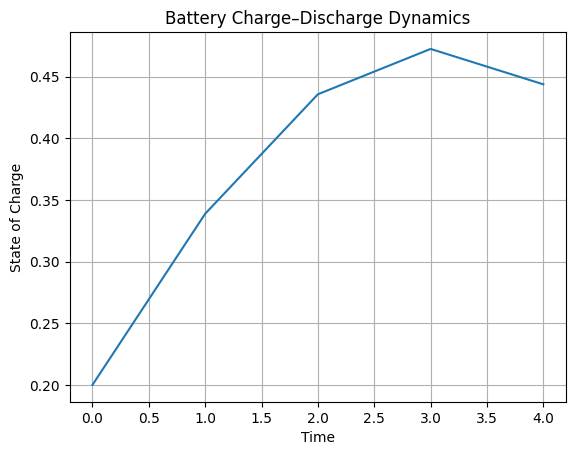

In [8]:
plot_soc(
    solution.t,
    solution.y[0],
    save_path="battery_model/figures/soc_vs_time.png"
)
